In [6]:
import sys
import yaml
import numpy as np
sys.path.append("..")
from src.data_generation.SSVI import ssvi, sample_params

cfg = yaml.safe_load(open("../config.yaml"))["ssvi_prior"]

In [7]:
ttms = np.linspace(1/12, 1.0, 50)
ks   = np.linspace(-0.5, 0.5, 50)
np.random.seed(0)
rho, nu, gamma, v_bar, v0, kappa = sample_params(cfg, n=1000)

In [8]:
surfaces = ssvi(ttms, ks, rho, nu, gamma, v_bar, v0, kappa) 
surfaces[0]

array([[0.27245812, 0.26912083, 0.265744  , ..., 0.09362084, 0.09317475,
        0.09288513],
       [0.26249266, 0.25942728, 0.25632761, ..., 0.09492329, 0.09408314,
        0.09343013],
       [0.25464522, 0.25179298, 0.2489104 , ..., 0.09668308, 0.09550417,
        0.09453055],
       ...,
       [0.17952247, 0.17845528, 0.17738285, ..., 0.12344845, 0.12215933,
        0.12087197],
       [0.17900168, 0.1779449 , 0.17688297, ..., 0.12352617, 0.12225075,
        0.12097687],
       [0.17849498, 0.17744832, 0.17639659, ..., 0.12360085, 0.12233877,
        0.12107803]])

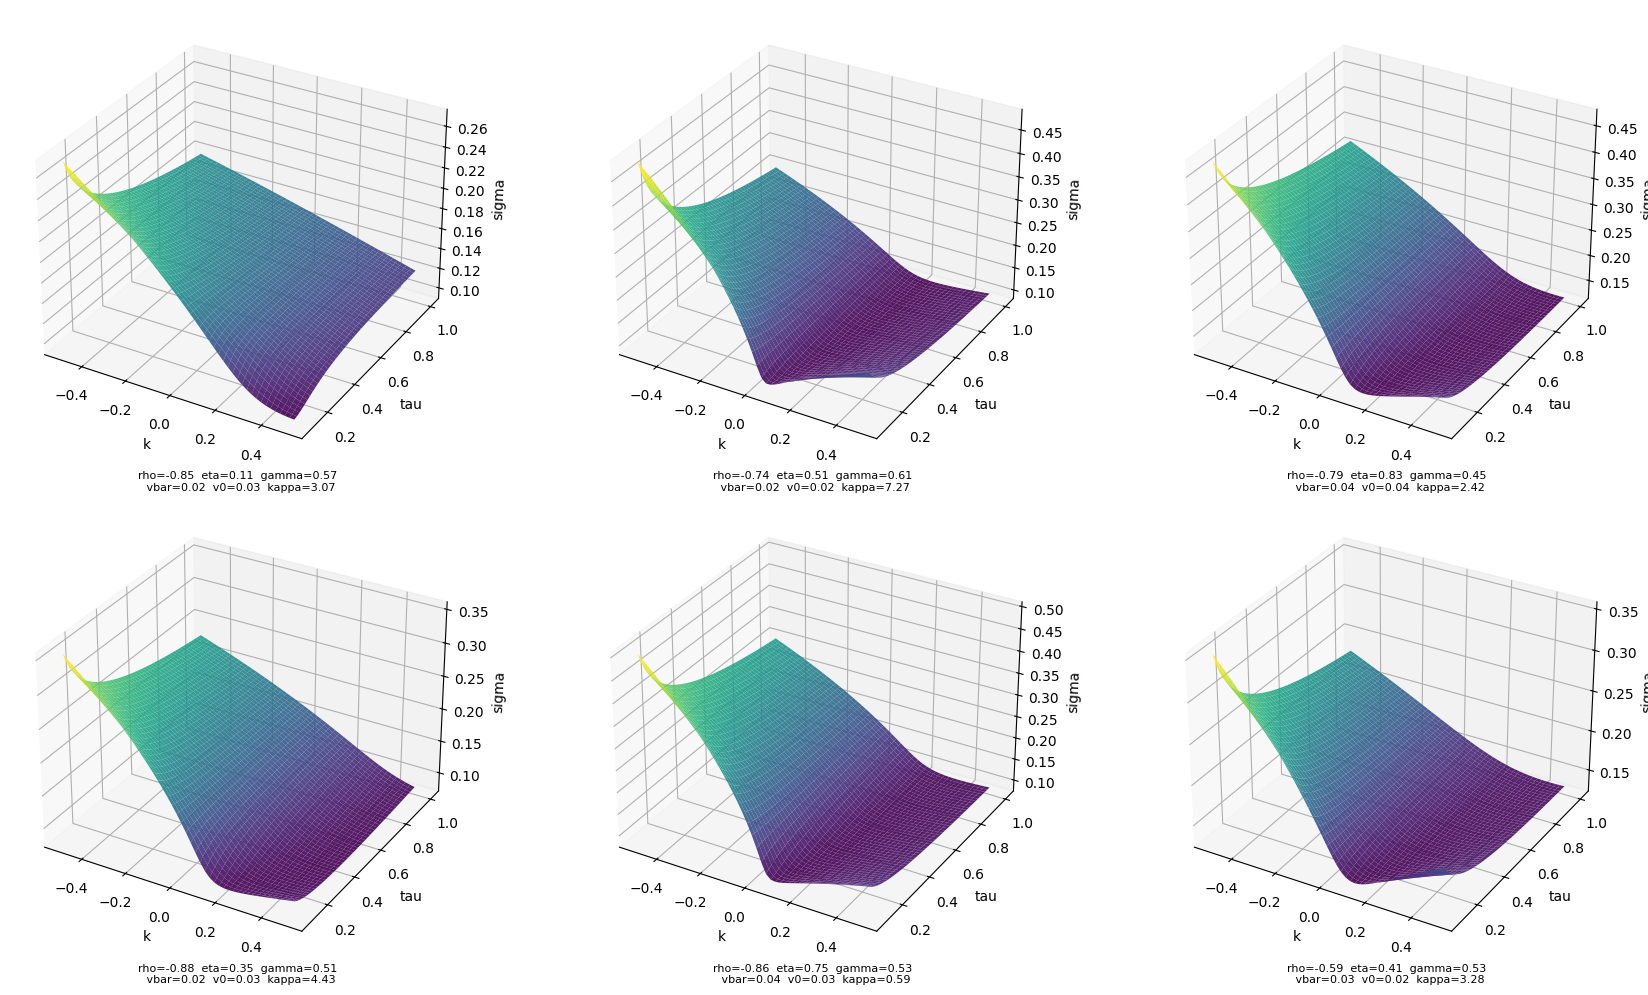

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": "3d"})
K, T = np.meshgrid(ks, ttms)

for i, ax in enumerate(axes.flat):
    iv = surfaces[i]
    ax.plot_surface(K, T, iv, cmap="viridis", edgecolor="none", alpha=0.9)
    ax.set_xlabel("k")
    ax.set_ylabel("tau")
    ax.set_zlabel("sigma")
    label = (
        f"rho={rho[i]:.2f}  eta={nu[i]:.2f}  gamma={gamma[i]:.2f} \n "
        f"vbar={v_bar[i]:.2f}  v0={v0[i]:.2f}  kappa={kappa[i]:.2f}"
    )
    ax.text2D(0.5, -0.05, label, transform=ax.transAxes, ha="center", fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# --- Arbitrage checks (analytic derivatives) ---
ttms_3d = ttms[None, :, None]
ks_3d = ks[None, None, :]
rho_3d, nu_3d, gamma_3d, v_bar_3d, v0_3d, kappa_3d = [
    x[:, None, None] for x in (rho, nu, gamma, v_bar, v0, kappa)
]

theta = v_bar_3d * ttms_3d + (v0_3d - v_bar_3d) / kappa_3d * (1 - np.exp(-kappa_3d * ttms_3d))
phi = nu_3d / (theta**gamma_3d * (1 + theta)**(1 - gamma_3d))

u = phi * ks_3d + rho_3d
D = np.sqrt(u**2 + 1 - rho_3d**2)

w = theta / 2 * (1 + rho_3d * phi * ks_3d + D)
dw = theta * phi / 2 * (rho_3d + u / D)
d2w = theta * phi**2 / 2 * (1 - rho_3d**2) / D**3

# 1) Calendar spread: total variance non-decreasing in t
dw_dt = np.diff(w, axis=1)
cal_violations = (dw_dt < -1e-12).any(axis=(1, 2))
print(f"Calendar spread violations: {cal_violations.mean()*100:.1f}% ({cal_violations.sum()}/{len(cal_violations)})")

# 2) Butterfly: density g(k) >= 0
g = (1 - ks_3d * dw / (2 * w))**2 - dw**2 / 4 * (1/w + 0.25) + d2w / 2
butterfly_violations = (g < -1e-10).any(axis=(1, 2))
print(f"Butterfly violations:       {butterfly_violations.mean()*100:.1f}% ({butterfly_violations.sum()}/{len(butterfly_violations)})")
print(f"Any arbitrage:              {(cal_violations | butterfly_violations).mean()*100:.1f}%")
print(f"Min g value:                {g.min():.6f}")

Calendar spread violations: 0.0% (0/1000)
Butterfly violations:       0.0% (0/1000)
Any arbitrage:              0.0%
Min g value:                0.230644
